# Mortality Experience Visualization

## Overview

This notebook visualizes the results of the mortality experience study, focusing on Actual vs Expected (A/E) ratios and claim distributions.

Visualizations help identify patterns in mortality deviations and highlight key risk segments across the portfolio.

## Objectives

- Visualize A/E ratios by age and gender  
- Identify high-risk segments  
- Analyze claim distributions  
- Support actuarial insights with visual evidence

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
portfolio = pd.read_csv("../data/processed/portfolio.csv")

In [3]:
portfolio["age_group"] = pd.cut(
    portfolio["age"],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
)

portfolio["expected_claim"] = (
    portfolio["expected_death_probability"] * portfolio["sum_insured"]
)

/tmp/ipykernel_647/4126988919.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = portfolio.groupby("age_group").agg(


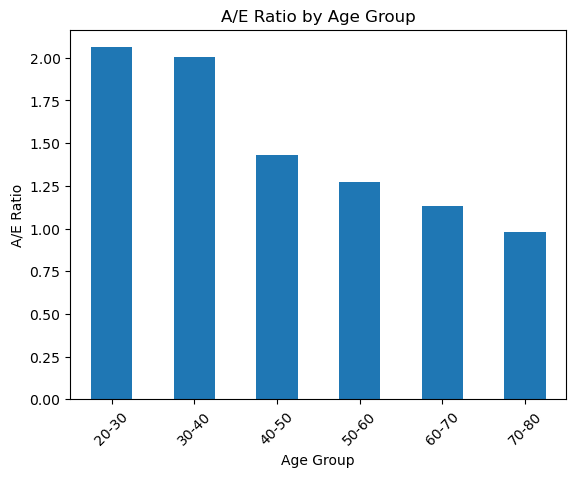

In [4]:
## A/E Ratio by Age Group
age_analysis = portfolio.groupby("age_group").agg(
    expected_deaths=("expected_death_probability", "sum"),
    actual_deaths=("actual_death", "sum")
)

age_analysis["ae_ratio"] = (
    age_analysis["actual_deaths"] / age_analysis["expected_deaths"]
)

age_analysis["ae_ratio"].plot(kind="bar")
plt.title("A/E Ratio by Age Group")
plt.xlabel("Age Group")
plt.ylabel("A/E Ratio")
plt.xticks(rotation=45)
plt.show()

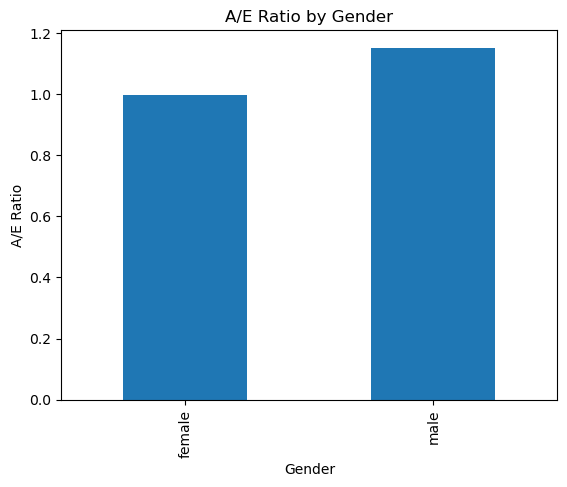

In [5]:
## A/E Ratio by Gender
gender_analysis = portfolio.groupby("sex").agg(
    expected_deaths=("expected_death_probability", "sum"),
    actual_deaths=("actual_death", "sum")
)

gender_analysis["ae_ratio"] = (
    gender_analysis["actual_deaths"] / gender_analysis["expected_deaths"]
)

gender_analysis["ae_ratio"].plot(kind="bar")
plt.title("A/E Ratio by Gender")
plt.xlabel("Gender")
plt.ylabel("A/E Ratio")
plt.show()

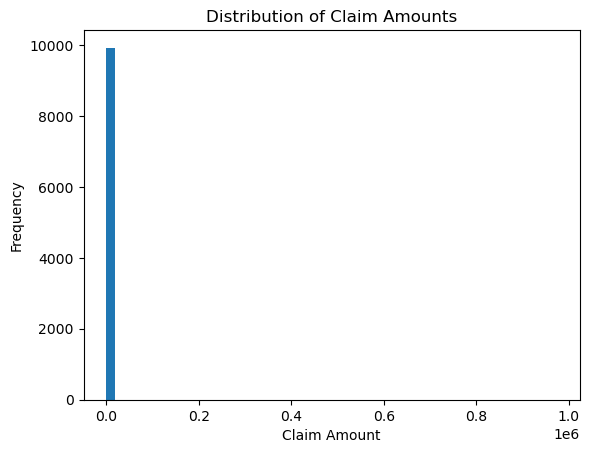

In [6]:
## Distribution of Claim Amounts
plt.hist(portfolio["claim_amount"], bins=50)
plt.title("Distribution of Claim Amounts")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_647/421262654.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  claims_by_age = portfolio.groupby("age_group").agg(


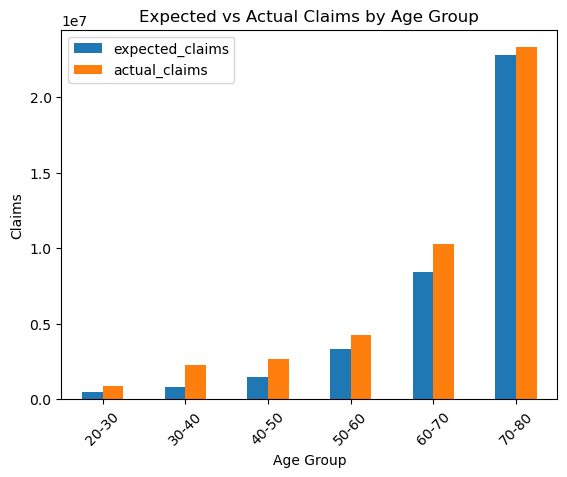

In [7]:
## Expected vs Actual Claims by Age Group
claims_by_age = portfolio.groupby("age_group").agg(
    expected_claims=("expected_claim", "sum"),
    actual_claims=("claim_amount", "sum")
)

claims_by_age.plot(kind="bar")
plt.title("Expected vs Actual Claims by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claims")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_647/2321338739.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = portfolio.groupby(["age_group", "sex"]).agg(


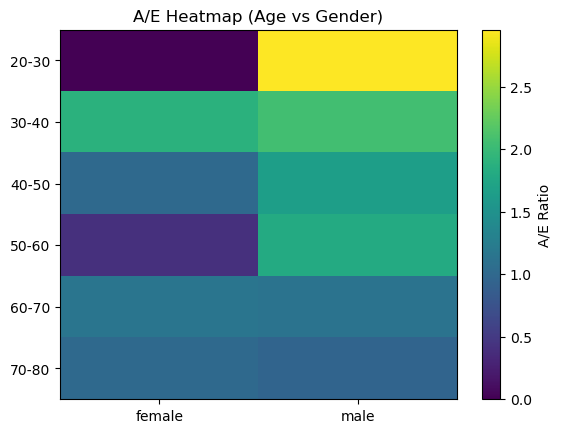

In [8]:
pivot = portfolio.groupby(["age_group", "sex"]).agg(
    expected=("expected_death_probability", "sum"),
    actual=("actual_death", "sum")
)

pivot["ae_ratio"] = pivot["actual"] / pivot["expected"]

pivot = pivot["ae_ratio"].unstack()

plt.imshow(pivot, aspect="auto")
plt.colorbar(label="A/E Ratio")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("A/E Heatmap (Age vs Gender)")
plt.show()

## Key Visualization Insights

- Mortality experience exceeds expectations in middle and older age groups, particularly between ages 50–70.

- Male policyholders show consistently higher A/E ratios compared to females, indicating elevated mortality risk.

- Claim distribution is highly skewed, with a small number of large claims driving overall portfolio losses.

- Actual claims exceed expected claims in key segments, reinforcing the need for refined mortality assumptions.

## Conclusion

Visual analysis confirms that mortality deviations are not uniform across the portfolio. Segment-level insights highlight areas where actuarial assumptions may require adjustment to improve pricing accuracy and risk management.